In [1]:
! pip install torchmetrics pandas datasets numpy torchmetrics scikit-learn seaborn torchcodec torchaudio librosa ipywidgets torchvision wandb


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
sr = 16000

data_dir = "/home/pierre/Documents/Projects/PST4/AI/data/raw/hibou_dataset/other"

files = sorted([f for f in os.listdir(data_dir) if f.lower().endswith(".wav")])
print(f"Found {len(files)} WAV files")

Found 3591 WAV files


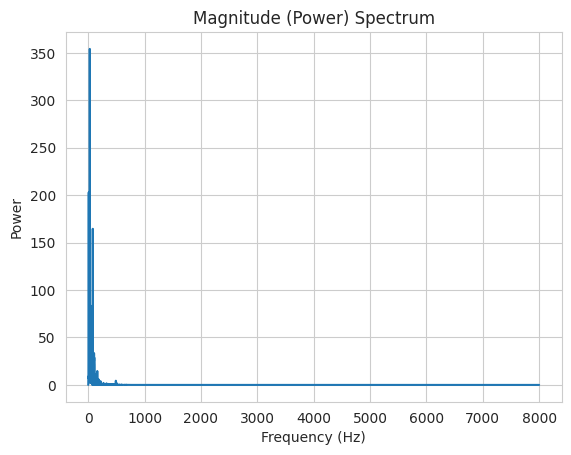

In [4]:
def plot_frequency_spectrum(wav, sample_rate):
    """
    wav: 1D numpy array (audio signal)
    sample_rate: sampling frequency in Hz
    """
    # Number of samples
    N = len(wav)
    fft_values = np.fft.fft(wav)
    freqs = np.fft.fftfreq(N, d=1/sample_rate)
    positive_freqs = freqs[:N // 2]
    power = np.abs(fft_values[:N // 2]) ** 2
    plt.figure()
    plt.plot(positive_freqs, power)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title("Magnitude (Power) Spectrum")
    plt.show()

audio, _ = librosa.load(os.path.join(data_dir, files[0]), sr=sr, mono=True)
plot_frequency_spectrum(audio, sr)

In [5]:
def analyze_frequency(file_path, sr=16000, n_fft=2048, hop_length=512):
    """Load audio and compute magnitude spectrum (average over time)."""
    audio, _ = librosa.load(file_path, sr=sr, mono=True)
    stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude = np.abs(stft)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    # Average magnitude over time
    avg_magnitude = np.mean(magnitude, axis=1)
    return freqs, avg_magnitude, audio, sr


results = {}
for f in files:
    path = os.path.join(data_dir, f)
    try:
        freqs, avg_mag, audio, sr = analyze_frequency(path)
        results[f] = {"freqs": freqs, "avg_magnitude": avg_mag, "sr": sr, "duration": len(audio) / sr}
    except Exception as e:
        print(f"Error processing {f}: {e}")


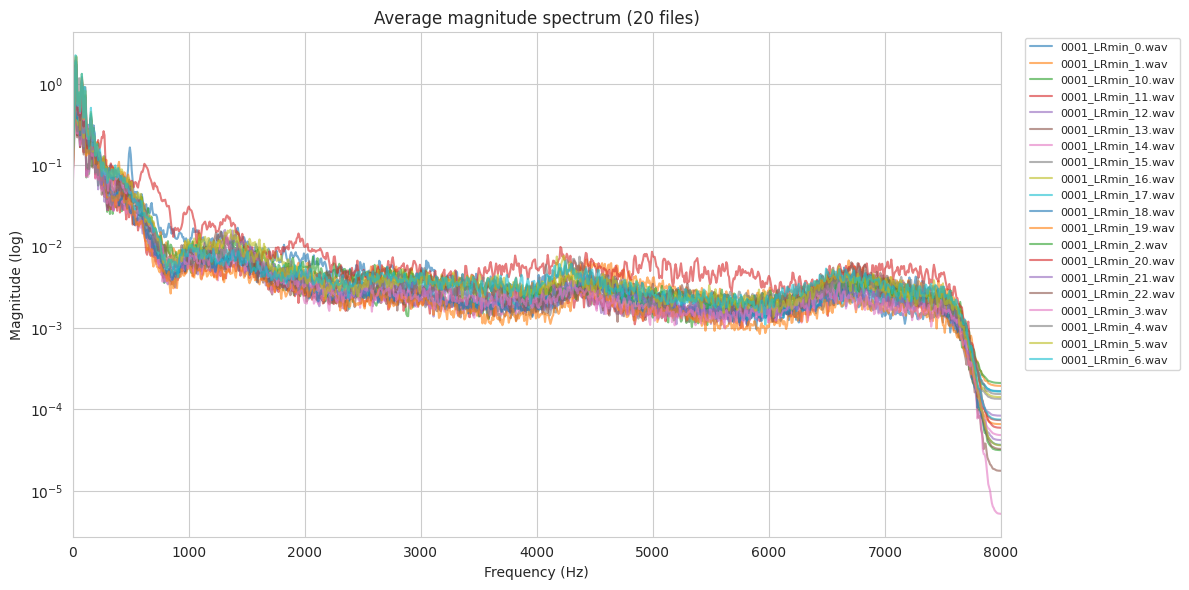

In [6]:
# Plot average magnitude spectrum for each file (first 20 to avoid clutter, or all if fewer)
n_show = min(20, len(results))
fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, data) in enumerate(list(results.items())[:n_show]):
    ax.semilogy(data["freqs"], data["avg_magnitude"] + 1e-10, alpha=0.6, label=name[:30])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (log)") 
ax.set_title(f"Average magnitude spectrum ({n_show} files)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xlim(0, 8000)  # Focus on typical audio range
plt.tight_layout()
plt.show()

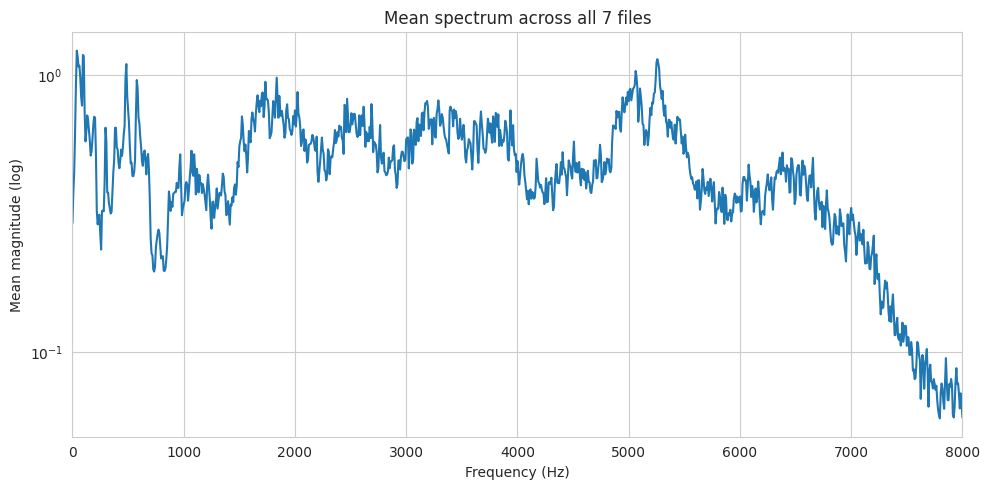

In [37]:
# Mean spectrum across all files
all_mags = np.stack([d["avg_magnitude"] for d in results.values()])
mean_spectrum = np.mean(all_mags, axis=0)
freqs_ref = list(results.values())[0]["freqs"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(freqs_ref, mean_spectrum + 1e-10)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Mean magnitude (log)")
ax.set_title(f"Mean spectrum across all {len(results)} files")
ax.set_xlim(0, 8000)
plt.tight_layout()
plt.show()

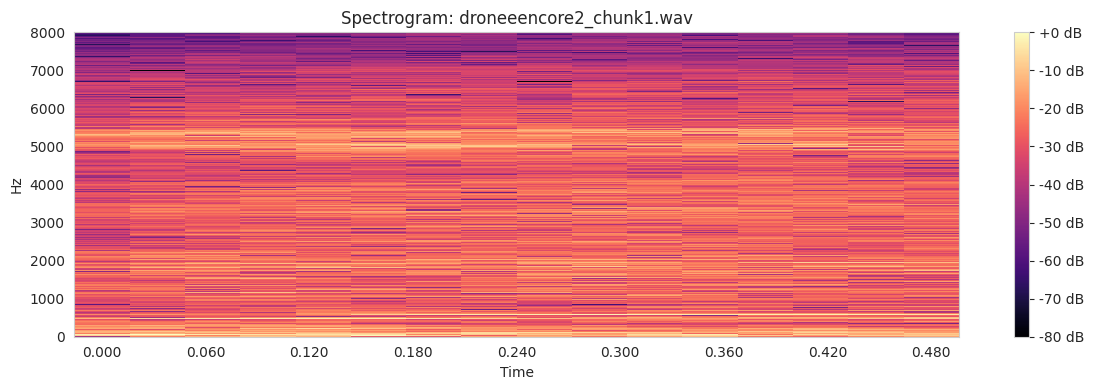

In [38]:
# Spectrogram of first file
first_name = list(results.keys())[0]
path = os.path.join(data_dir, first_name)
audio, sr = librosa.load(path, sr=16000, mono=True)
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=2048, hop_length=512)), ref=np.max)

fig, ax = plt.subplots(figsize=(12, 4))
img = librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz", ax=ax)
fig.colorbar(img, ax=ax, format="%+2.0f dB")
ax.set_title(f"Spectrogram: {first_name}")
plt.tight_layout()
plt.show()